<a href="https://colab.research.google.com/github/Pradeep-Kumar-Panga/DecodingComplexities/blob/main/CentralLimitTheorem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Central Limit Theorem

Central Limit Theorem states that when a sufficiently large number of samples (>= 30) taken from data of any distribution, the result data always follows a normal distribution.

**How do we do this?**

1.   Extract random samples from the input data (of any distribution).
2.   Average the random samples taken and repeat this process.
3.   Resulting Distribution follows a normal distribution.



In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Generate a random data with uniform distribution.

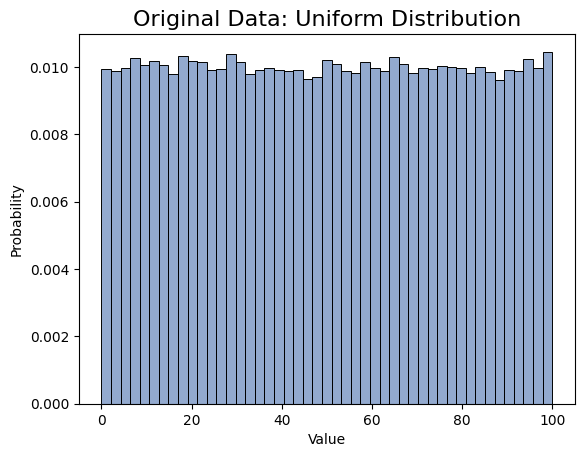

In [23]:
# Generate a large "Population" of Uniform Data
# 100,000 data points between 0 and 100
population_size = 100000
uniform_data = np.random.uniform(0, 100, population_size)

# Visualize the Raw data
plt.figure()
sns.histplot(uniform_data, stat="density", color="#4c72b0", alpha=0.6)
plt.title("Original Data: Uniform Distribution", fontsize=16)
plt.xlabel("Value")
plt.ylabel("Probability")
plt.show()

# Implement Central Limit Theorem

1. Extract 'n' number of samples from the original data set.
2. Average the samples taken.
3. Repeat this for a 1000 times.

In [24]:
def simulate_clt(data, n_samples_to_average, n_experiments=1000):
    """
    Simulates the Central Limit Theorem.

    Args:
        data: The population array (uniform distribution).
        n_samples_to_average: How many numbers to grab and average (n).
        n_experiments: How many times to repeat the experiment.

    Returns:
        A list of sample means.
    """
    sample_means = []

    for _ in range(n_experiments):
        # Pick 'n' random points from the messy data
        sample = np.random.choice(data, n_samples_to_average)
        # Calculate the mean
        mean = np.mean(sample)
        # Store it
        sample_means.append(mean)

    return np.array(sample_means)

# Experiment Central Limit Theorem

1.   With one sample (raw data samples, no average)
2.   With two samples (and averaging)
3.   With thirty samples (and averaging)


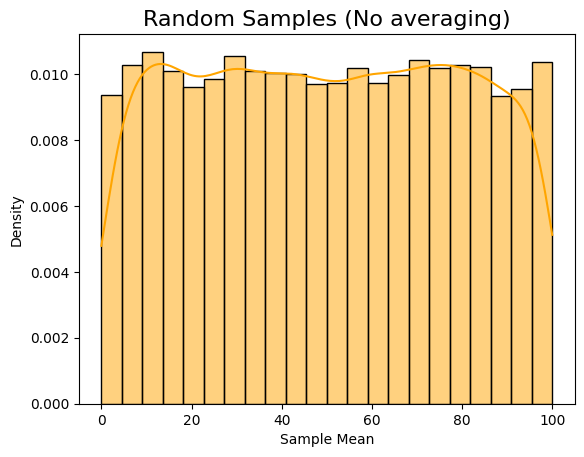

In [25]:
# Run Simulation with n=1
means_n1 = simulate_clt(uniform_data, n_samples_to_average=1, n_experiments=10000)

# Visualize
plt.figure()
sns.histplot(means_n1, stat="density", color="orange", kde=True)
plt.title("Random Samples (No averaging)", fontsize=16)
plt.xlabel("Sample Mean")
plt.show()

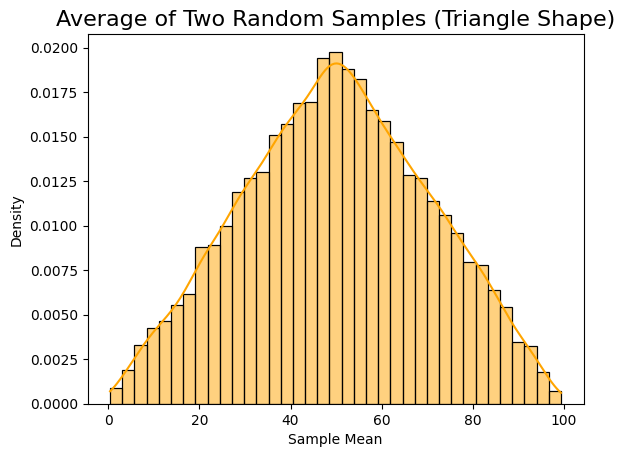

In [26]:
# Run Simulation with n=2
means_n2 = simulate_clt(uniform_data, n_samples_to_average=2, n_experiments=10000)

# Visualize
plt.figure()
sns.histplot(means_n2, stat="density", color="orange", kde=True)
plt.title("Average of Two Random Samples (Triangle Shape)", fontsize=16)
plt.xlabel("Sample Mean")
plt.show()

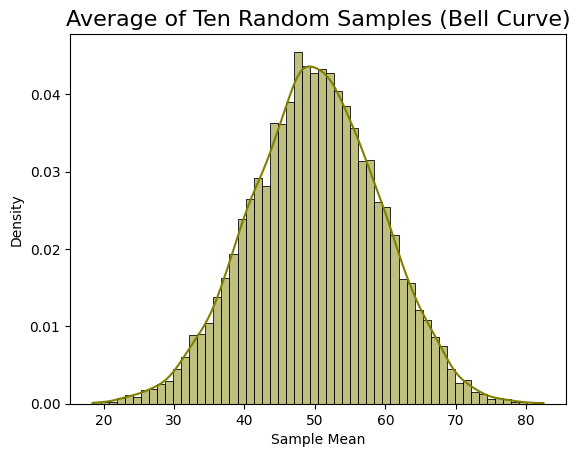

In [27]:
# Run Simulation with n=10
means_n10 = simulate_clt(uniform_data, n_samples_to_average=10, n_experiments=10000)

# Visualize
plt.figure()
sns.histplot(means_n10, stat="density", color="olive", kde=True)
plt.title("Average of Ten Random Samples (Bell Curve)", fontsize=16)
plt.xlabel("Sample Mean")
plt.show()

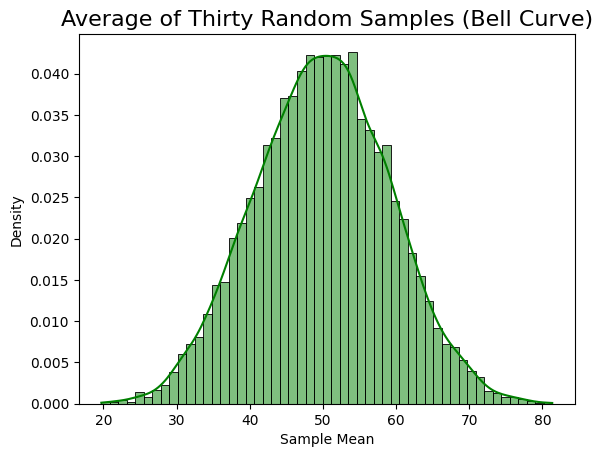

In [28]:
# Run Simulation with n=30
means_n30 = simulate_clt(uniform_data, n_samples_to_average=10, n_experiments=10000)

# Visualize
plt.figure()
sns.histplot(means_n30, stat="density", color="green", kde=True)
plt.title("Average of Thirty Random Samples (Bell Curve)", fontsize=16)
plt.xlabel("Sample Mean")
plt.show()

Generate another set of random data which follows exponential distribution and try Central Limit Theorem on this data.

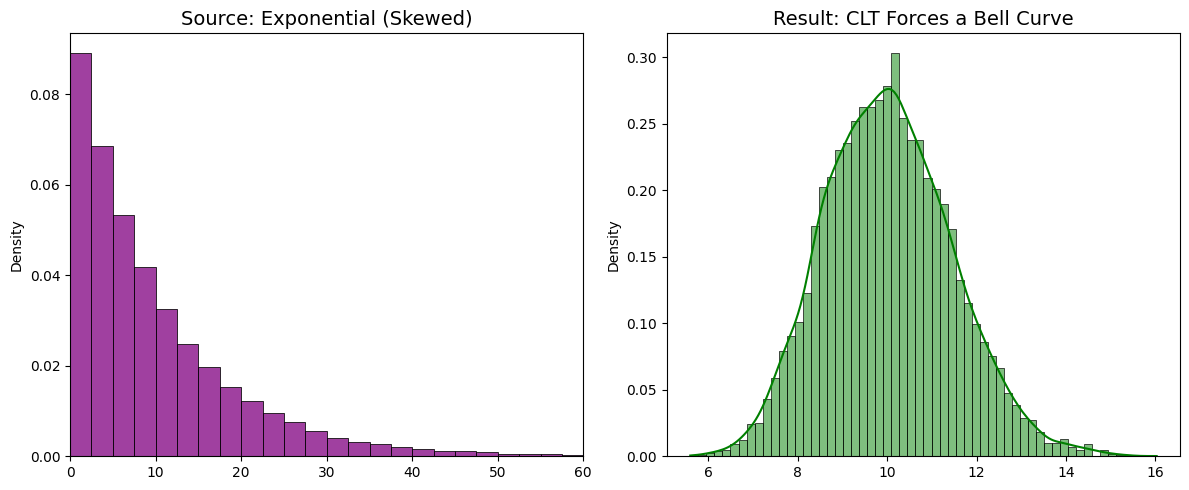

In [29]:
# Generate Skewed Data
exponential_data = np.random.exponential(scale=10, size=population_size)

# Visualize Source
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(exponential_data, stat="density", color="purple", bins=50)
plt.title("Source: Exponential (Skewed)", fontsize=14)
plt.xlim(0, 60)

# Run Simulation (n=50)
means_exp = simulate_clt(exponential_data, n_samples_to_average=50, n_experiments=10000)

# Visualize Result
plt.subplot(1, 2, 2)
sns.histplot(means_exp, stat="density", color="green", kde=True)
plt.title("CLT: Results in a a Bell Curve", fontsize=14)

plt.tight_layout()
plt.show()